In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import zipfile

# Path to the uploaded zip file (as per the kernel state)
zip_file_path = '/content/archive.zip'
csv_file_name = 'spam.csv' # Assuming the CSV file inside is named spam.csv

# Extract the CSV file from the zip archive
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extract(csv_file_name, path='/content/') # Extract to /content/

# Now read the extracted CSV file
df = pd.read_csv(f"/content/{csv_file_name}", encoding="latin-1")

In [10]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [11]:
df=df.iloc[:,:2]

In [24]:
import string
import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [25]:
df.drop_duplicates(inplace=True)
def preprocess(text):
  text = text.lower()

  text = text.translate(str.maketrans('', '', string.punctuation))
  tokens = word_tokenize(text)
  stop_words = set(stopwords.words('english'))
  tokens = [word for word in tokens if word not in stop_words]
  stemmer = PorterStemmer()
  tokens = [stemmer.stem(word) for word in tokens]
  return ' '.join(tokens)

In [26]:
df.rename(columns={'v1': 'Label', 'v2': 'messages'}, inplace=True)
df["messages"] = df["messages"].apply(preprocess)

In [27]:
df.shape

(5169, 2)

In [30]:
from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()
df['Label']=l.fit_transform(df['Label'])

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=4000)
x = tfidf.fit_transform(df['messages'])
y=df['Label']

In [88]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=42)

In [89]:
x_train.shape

(4652, 4000)

In [90]:
x_test.shape

(517, 4000)

In [91]:
y_test.shape

(517,)

In [92]:
y_train.shape

(4652,)

In [93]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(x_train,y_train)

MultinomialNB()

In [94]:
y_pred=model.predict(x_test)

In [95]:
from sklearn.linear_model import LogisticRegression
l=LogisticRegression()
l.fit(x_train,y_train)
y_pred_l=l.predict(x_test)

In [96]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


0.9787234042553191
[[443   0]
 [ 11  63]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       443
           1       1.00      0.85      0.92        74

    accuracy                           0.98       517
   macro avg       0.99      0.93      0.95       517
weighted avg       0.98      0.98      0.98       517



In [97]:
print(accuracy_score(y_test,y_pred_l))
print(confusion_matrix(y_test,y_pred_l))
print(classification_report(y_test,y_pred_l))


0.9574468085106383
[[440   3]
 [ 19  55]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       443
           1       0.95      0.74      0.83        74

    accuracy                           0.96       517
   macro avg       0.95      0.87      0.90       517
weighted avg       0.96      0.96      0.96       517



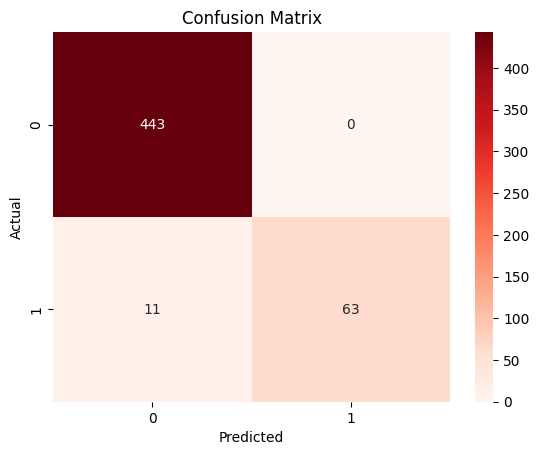

In [105]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d',cmap='Reds')
plt.plot()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("Confusion Matrix.png",
            dpi=300,bbox_inches="tight")
plt.show()


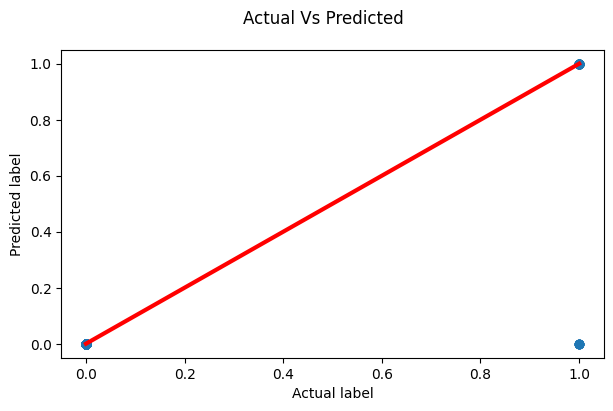

In [103]:
plt.figure(figsize=(7,4))
plt.scatter(y_test,y_pred,alpha=0.7)
plt.plot([y_test.min(),y_test.max()],
        [y_test.min(),y_test.max()],color="Red",linewidth=3
        )
plt.xlabel("Actual label")
plt.ylabel("Predicted label")
plt.suptitle("Actual Vs Predicted")
plt.savefig("Actual Vs Predicted.png",
            dpi=300,bbox_inches="tight")
plt.show()

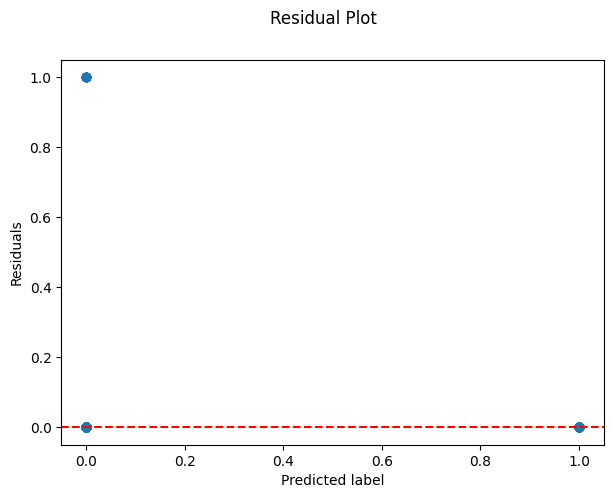

In [104]:
residuals= y_test - y_pred
plt.figure(figsize=(7,5))
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color="red",linestyle="--")
plt.xlabel("Predicted label")
plt.ylabel("Residuals")
plt.suptitle("Residual Plot")
plt.savefig("Residual Plot.png",
            dpi=300,bbox_inches="tight")
plt.show()

In [99]:
print(f"Training score:{model.score(x_train,y_train)}")
print(f"Testing score:{model.score(x_test,y_test)}")

Training score:0.9793637145313844
Testing score:0.9787234042553191


In [101]:
message=["I love icecream yummi"]
message_vector=tfidf.transform(message)
prediction=model.predict(message_vector)
if prediction[0]==1:
  print('spam')
else:
  print("ham")

ham


In [102]:
import joblib
joblib.dump(model,'spam_model.pkl')
joblib.dump(tfidf,'tfidf.pkl')

['tfidf.pkl']